# ARX(5,1,2) Feature Ablation Study

Notebook này trả lời câu hỏi: FIT tăng là do feature nào trong phần feature engineering?

Lưu ý thuật ngữ: trong notebook này, "feature" là biến đầu vào của mô hình. "Tham số" theo nghĩa toán học là hệ số `theta` sau khi ước lượng. Báo cáo có thể gọi là "biến/đặc trưng" để tránh nhầm.


## 1. Import và cấu hình


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = Path.cwd()
PROJECT_ROOT = WORK_DIR.parent if WORK_DIR.name.startswith("ARX_Model_Version") else WORK_DIR
VERSION_DIR = PROJECT_ROOT / "ARX_Model_Version 512"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from arx_pipeline import (
    DataConfig,
    SplitConfig,
    ModelConfig,
    load_or_generate_data,
    split_time_series,
    build_regression_matrix,
    estimate_ols,
    evaluate_slice,
    compute_metrics,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RIDGE_ALPHAS = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
CLIP_QUANTILES = (0.01, 0.99)
NA, NB, NK = 5, 1, 2


## 2. Load dữ liệu và tạo feature


In [2]:
DATA_CONFIG = DataConfig(
    csv_path=PROJECT_ROOT / "greenhouse_data.csv",
    generator_script_path=PROJECT_ROOT / "data_generator.py",
    force_regenerate_from_script=False,
    auto_save_generated_csv=True,
)
SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)

BASELINE_INPUT_COLS = (
    "Temperature",
    "Humidity",
    "Light",
    "Drip",
    "Mist",
    "Fan",
)

ENGINEERED_FEATURES = (
    "Light_log",
    "Temp_x_Humi",
    "Temp_x_Light",
    "Humi_x_Light",
    "SP_Center",
    "SP_Width",
    "Month_sin",
    "Month_cos",
    "Season_sin",
    "Season_cos",
)

FEATURE_GROUPS = {
    "Light transform": ("Light_log",),
    "Environment interactions": ("Temp_x_Humi", "Temp_x_Light", "Humi_x_Light"),
    "Setpoint context": ("SP_Center", "SP_Width"),
    "Month cyclic": ("Month_sin", "Month_cos"),
    "Season cyclic": ("Season_sin", "Season_cos"),
}


def build_augmented_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    df["Light_log"] = np.log1p(df["Light"].clip(lower=0))
    df["Temp_x_Humi"] = df["Temperature"] * df["Humidity"]
    df["Temp_x_Light"] = df["Temperature"] * df["Light_log"]
    df["Humi_x_Light"] = df["Humidity"] * df["Light_log"]
    df["SP_Center"] = 0.5 * (df["Soil_Low_SP"] + df["Soil_High_SP"])
    df["SP_Width"] = df["Soil_High_SP"] - df["Soil_Low_SP"]
    df["Month_sin"] = np.sin(2.0 * np.pi * df["Month"] / 12.0)
    df["Month_cos"] = np.cos(2.0 * np.pi * df["Month"] / 12.0)
    season_map = {"spring": 0, "summer": 1, "autumn": 2, "winter": 3}
    season_num = df["Season"].map(season_map).fillna(0).astype(float)
    df["Season_sin"] = np.sin(2.0 * np.pi * season_num / 4.0)
    df["Season_cos"] = np.cos(2.0 * np.pi * season_num / 4.0)
    return df


df_full_raw, true_params, data_source = load_or_generate_data(DATA_CONFIG)
df_full = build_augmented_df(df_full_raw)
df_train, df_val, df_test = split_time_series(df_full, SPLIT_CONFIG)

print("Nguồn dữ liệu:", data_source)
print("Số mẫu:", len(df_full), "| Train:", len(df_train), "| Validation:", len(df_val), "| Test:", len(df_test))
pd.DataFrame({
    "raw_inputs": pd.Series(BASELINE_INPUT_COLS),
    "engineered_features": pd.Series(ENGINEERED_FEATURES),
})


Nguồn dữ liệu: CSV:greenhouse_data.csv
Số mẫu: 105120 | Train: 63072 | Validation: 21024 | Test: 21024


,raw_inputs,engineered_features
0,Temperature,Light_log
1,Humidity,Temp_x_Humi
2,Light,Temp_x_Light
3,Drip,Humi_x_Light
4,Mist,SP_Center
5,Fan,SP_Width
6,NaN,Month_sin
7,NaN,Month_cos
8,NaN,Season_sin
9,NaN,Season_cos


## 3. Hàm fit/evaluate cho một tập feature


In [3]:
def fit_zscore_stats(df_train: pd.DataFrame, cols: tuple[str, ...]) -> dict[str, dict[str, float]]:
    stats = {}
    for col in cols:
        mean = float(df_train[col].astype(float).mean())
        std = float(df_train[col].astype(float).std(ddof=0))
        if not np.isfinite(std) or std < 1e-12:
            std = 1.0
        stats[col] = {"mean": mean, "std": std}
    return stats


def apply_zscore(df_in: pd.DataFrame, stats: dict[str, dict[str, float]]) -> pd.DataFrame:
    df_out = df_in.copy()
    for col, st in stats.items():
        df_out[col] = (df_out[col].astype(float) - st["mean"]) / st["std"]
    return df_out


def inverse_y(values: np.ndarray, stats: dict[str, dict[str, float]]) -> np.ndarray:
    st = stats["Soil_Moisture"]
    return np.asarray(values, dtype=float) * st["std"] + st["mean"]


def estimate_ridge(x_mat: np.ndarray, y_vec: np.ndarray, alpha: float, include_intercept: bool = True) -> np.ndarray:
    n_params = x_mat.shape[1]
    penalty = np.eye(n_params, dtype=float)
    if include_intercept:
        penalty[-1, -1] = 0.0
    return np.linalg.pinv(x_mat.T @ x_mat + float(alpha) * penalty) @ x_mat.T @ y_vec


def evaluate_real(split_name: str, df_split_z: pd.DataFrame, theta: np.ndarray, config: ModelConfig, stats: dict[str, dict[str, float]]) -> dict:
    ev = evaluate_slice(split_name, df_split_z, theta, config, true_theta=None, n_step=12)
    arrays = ev["arrays"]
    return {
        "metrics_1step": compute_metrics(inverse_y(arrays["y_true_1step"], stats), inverse_y(arrays["y_pred_1step"], stats), len(theta)),
        "metrics_12step": compute_metrics(inverse_y(arrays["y_true_sim"], stats), inverse_y(arrays["y_pred_n_step"], stats), len(theta)),
        "metrics_sim": compute_metrics(inverse_y(arrays["y_true_sim"], stats), inverse_y(arrays["y_pred_sim"], stats), len(theta)),
    }


def fit_and_score(label: str, input_cols: tuple[str, ...], alpha_grid: list[float] = RIDGE_ALPHAS) -> dict:
    scale_cols = ("Soil_Moisture", *input_cols)
    stats = fit_zscore_stats(df_train, scale_cols)
    train_z = apply_zscore(df_train, stats)
    val_z = apply_zscore(df_val, stats)
    test_z = apply_zscore(df_test, stats)

    y_scale = stats["Soil_Moisture"]
    clip_low_real = float(df_train["Soil_Moisture"].quantile(CLIP_QUANTILES[0]))
    clip_high_real = float(df_train["Soil_Moisture"].quantile(CLIP_QUANTILES[1]))
    clip_bounds = (
        float((clip_low_real - y_scale["mean"]) / y_scale["std"]),
        float((clip_high_real - y_scale["mean"]) / y_scale["std"]),
    )

    config = ModelConfig(
        na=NA,
        nb=NB,
        nk=NK,
        include_intercept=True,
        input_cols=input_cols,
        output_col="Soil_Moisture",
        simulation_clip=clip_bounds,
    )

    x_train, y_train = build_regression_matrix(train_z, config)
    theta_ols, _, _ = estimate_ols(x_train, y_train)

    rows = []
    theta_by_alpha = {}
    for alpha in alpha_grid:
        theta = theta_ols if float(alpha) == 0.0 else estimate_ridge(x_train, y_train, float(alpha), include_intercept=True)
        theta_by_alpha[float(alpha)] = theta
        val_result = evaluate_real("Validation", val_z, theta, config, stats)
        test_result = evaluate_real("Test", test_z, theta, config, stats)
        rows.append({
            "alpha": float(alpha),
            "val_FIT_1step": val_result["metrics_1step"]["FIT"],
            "val_FIT_12step": val_result["metrics_12step"]["FIT"],
            "val_FIT_sim": val_result["metrics_sim"]["FIT"],
            "val_RMSE_sim": val_result["metrics_sim"]["RMSE"],
            "test_FIT_1step": test_result["metrics_1step"]["FIT"],
            "test_FIT_12step": test_result["metrics_12step"]["FIT"],
            "test_FIT_sim": test_result["metrics_sim"]["FIT"],
            "test_RMSE_sim": test_result["metrics_sim"]["RMSE"],
            "theta_l2": float(np.linalg.norm(theta)),
        })

    search_df = pd.DataFrame(rows).sort_values(
        ["val_FIT_sim", "val_FIT_12step", "val_FIT_1step"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    best = search_df.iloc[0].to_dict()
    best_alpha = float(best["alpha"])
    theta_hat = theta_by_alpha[best_alpha]

    return {
        "label": label,
        "n_inputs": len(input_cols),
        "input_cols": input_cols,
        "best_alpha": best_alpha,
        "rank": int(np.linalg.matrix_rank(x_train)),
        "n_params": len(config.param_names),
        "condition_number_xtx": float(np.linalg.cond(x_train.T @ x_train)),
        "theta_l2": float(np.linalg.norm(theta_hat)),
        **{k: float(v) for k, v in best.items() if k != "alpha"},
    }


## 4. Thí nghiệm 1 - Thêm từng feature engineering riêng lẻ


In [4]:
baseline_inputs = tuple(BASELINE_INPUT_COLS)
full_inputs = tuple(BASELINE_INPUT_COLS + ENGINEERED_FEATURES)

experiment_rows = []
experiment_rows.append(fit_and_score("Baseline: 6 raw inputs", baseline_inputs))
for feat in ENGINEERED_FEATURES:
    experiment_rows.append(fit_and_score(f"+ only {feat}", tuple(BASELINE_INPUT_COLS + (feat,))))
experiment_rows.append(fit_and_score("Full: raw + all engineered", full_inputs))

single_feature_df = pd.DataFrame(experiment_rows)
baseline_val = float(single_feature_df.loc[single_feature_df["label"].eq("Baseline: 6 raw inputs"), "val_FIT_sim"].iloc[0])
baseline_test = float(single_feature_df.loc[single_feature_df["label"].eq("Baseline: 6 raw inputs"), "test_FIT_sim"].iloc[0])
single_feature_df["gain_val_FIT_sim_vs_baseline"] = single_feature_df["val_FIT_sim"] - baseline_val
single_feature_df["gain_test_FIT_sim_vs_baseline"] = single_feature_df["test_FIT_sim"] - baseline_test

display(single_feature_df[[
    "label", "n_inputs", "best_alpha",
    "val_FIT_1step", "val_FIT_12step", "val_FIT_sim", "val_RMSE_sim",
    "test_FIT_1step", "test_FIT_12step", "test_FIT_sim", "test_RMSE_sim",
    "gain_val_FIT_sim_vs_baseline", "gain_test_FIT_sim_vs_baseline",
]].round(4))


,label,n_inputs,best_alpha,val_FIT_1step,val_FIT_12step,val_FIT_sim,val_RMSE_sim,test_FIT_1step,test_FIT_12step,test_FIT_sim,test_RMSE_sim,gain_val_FIT_sim_vs_baseline,gain_test_FIT_sim_vs_baseline
0,Baseline: 6 raw inputs,6,100.0,85.8350,66.6161,54.0059,1.3809,85.2606,57.7867,30.2629,2.0314,0.0000,0.0000
1,+ only Light_log,7,100.0,85.8344,66.6013,54.0060,1.3809,85.2596,57.7721,30.3541,2.0287,0.0001,0.0913
2,+ only Temp_x_Humi,7,100.0,85.8351,66.6159,53.9996,1.3811,85.2614,57.8121,30.3317,2.0293,-0.0064,0.0688
3,+ only Temp_x_Light,7,100.0,85.8345,66.5984,54.0110,1.3807,85.2594,57.7678,30.3609,2.0285,0.0050,0.0980
4,+ only Humi_x_Light,7,100.0,85.8349,66.6066,54.0179,1.3805,85.2600,57.7824,30.3912,2.0276,0.0120,0.1284
5,+ only SP_Center,7,0.0,86.2979,69.8168,68.8571,0.9350,85.8475,67.1439,66.3914,0.9790,14.8511,36.1286
6,+ only SP_Width,7,100.0,85.8350,66.6161,54.0059,1.3809,85.2606,57.7867,30.2629,2.0314,-0.0000,-0.0000
7,+ only Month_sin,7,100.0,84.7880,42.0559,10.0533,2.7005,83.7513,29.1472,-18.1215,3.4407,-43.9526,-48.3844
8,+ only Month_cos,7,0.0,86.0468,64.6628,58.1140,1.2575,85.6615,63.3841,58.2593,1.2159,4.1081,27.9965
9,+ only Season_sin,7,0.0,86.1662,67.6178,63.8553,1.0852,85.4407,58.2697,48.2246,1.5082,9.8494,17.9617


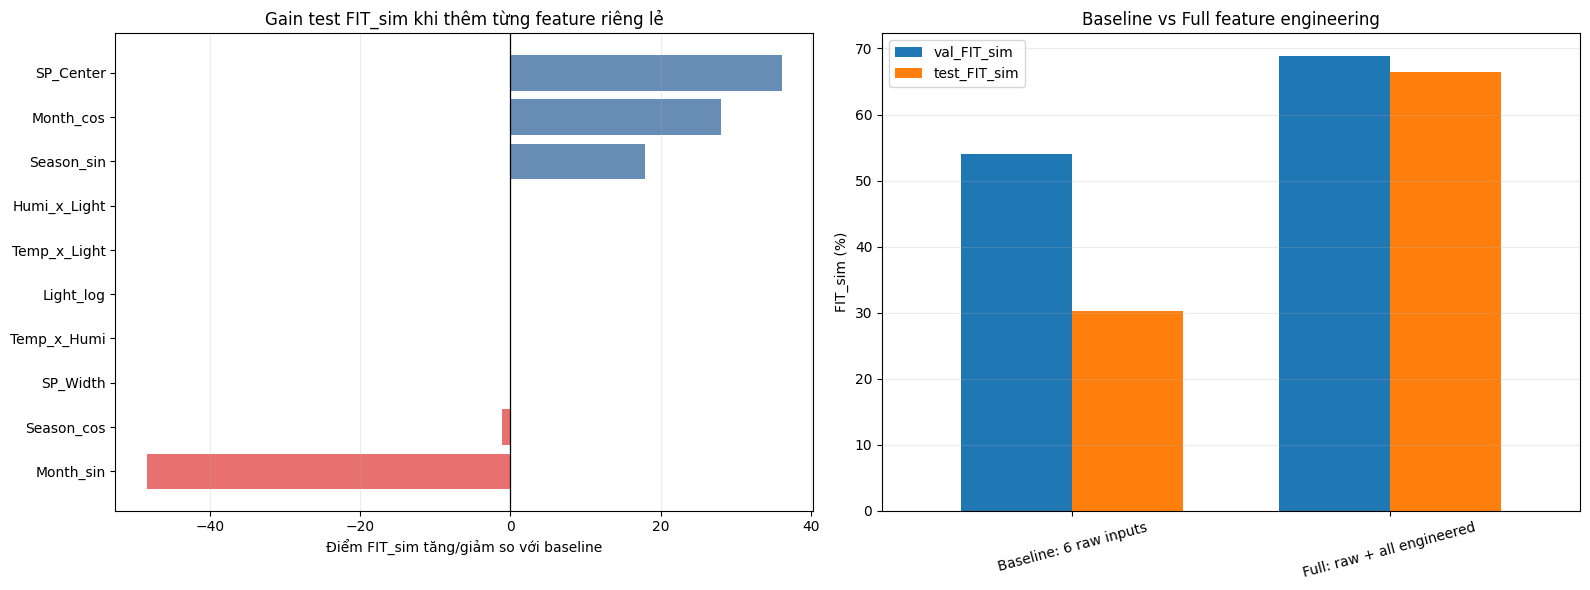

In [5]:
plot_df = single_feature_df[~single_feature_df["label"].str.startswith("Baseline") & ~single_feature_df["label"].str.startswith("Full")].copy()
plot_df["feature"] = plot_df["label"].str.replace("+ only ", "", regex=False)
plot_df = plot_df.sort_values("gain_test_FIT_sim_vs_baseline", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = np.where(plot_df["gain_test_FIT_sim_vs_baseline"] >= 0, "#4c78a8", "#e45756")
axes[0].barh(plot_df["feature"], plot_df["gain_test_FIT_sim_vs_baseline"], color=colors, alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_title("Gain test FIT_sim khi thêm từng feature riêng lẻ")
axes[0].set_xlabel("Điểm FIT_sim tăng/giảm so với baseline")
axes[0].grid(True, axis="x", alpha=0.25)

compare_df = single_feature_df[single_feature_df["label"].isin(["Baseline: 6 raw inputs", "Full: raw + all engineered"])].copy()
compare_df.plot(x="label", y=["val_FIT_sim", "test_FIT_sim"], kind="bar", ax=axes[1], width=0.7)
axes[1].set_title("Baseline vs Full feature engineering")
axes[1].set_xlabel("")
axes[1].set_ylabel("FIT_sim (%)")
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(title="")
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()


## 5. Thí nghiệm 2 - Leave-one-feature-out từ full model


In [6]:
loo_rows = []
full_result = fit_and_score("Full: raw + all engineered", full_inputs)
loo_rows.append(full_result)
for feat in ENGINEERED_FEATURES:
    kept_features = tuple(f for f in ENGINEERED_FEATURES if f != feat)
    loo_rows.append(fit_and_score(f"Full minus {feat}", tuple(BASELINE_INPUT_COLS + kept_features)))

loo_df = pd.DataFrame(loo_rows)
full_test = float(loo_df.loc[loo_df["label"].eq("Full: raw + all engineered"), "test_FIT_sim"].iloc[0])
full_val = float(loo_df.loc[loo_df["label"].eq("Full: raw + all engineered"), "val_FIT_sim"].iloc[0])
loo_df["drop_val_FIT_sim_vs_full"] = full_val - loo_df["val_FIT_sim"]
loo_df["drop_test_FIT_sim_vs_full"] = full_test - loo_df["test_FIT_sim"]

display(loo_df[[
    "label", "n_inputs", "best_alpha",
    "val_FIT_sim", "test_FIT_sim", "test_RMSE_sim",
    "drop_val_FIT_sim_vs_full", "drop_test_FIT_sim_vs_full",
]].round(4))


,label,n_inputs,best_alpha,val_FIT_sim,test_FIT_sim,test_RMSE_sim,drop_val_FIT_sim_vs_full,drop_test_FIT_sim_vs_full
0,Full: raw + all engineered,16,0.0,68.8411,66.4176,0.9782,0.0000,0.0000
1,Full minus Light_log,15,0.0,68.8383,66.4141,0.9783,0.0027,0.0035
2,Full minus Temp_x_Humi,15,0.0,68.8518,66.4083,0.9785,-0.0108,0.0092
3,Full minus Temp_x_Light,15,0.0,68.8381,66.4174,0.9782,0.0030,0.0002
4,Full minus Humi_x_Light,15,0.0,68.8415,66.4188,0.9782,-0.0004,-0.0012
5,Full minus SP_Center,15,0.0,61.9115,60.7400,1.1436,6.9296,5.6775
6,Full minus SP_Width,15,0.0,68.8411,66.4176,0.9782,-0.0000,-0.0000
7,Full minus Month_sin,15,0.0,68.8095,66.4038,0.9786,0.0316,0.0137
8,Full minus Month_cos,15,0.0,68.7887,66.4232,0.9780,0.0524,-0.0057
9,Full minus Season_sin,15,0.0,68.8593,66.4082,0.9785,-0.0182,0.0094


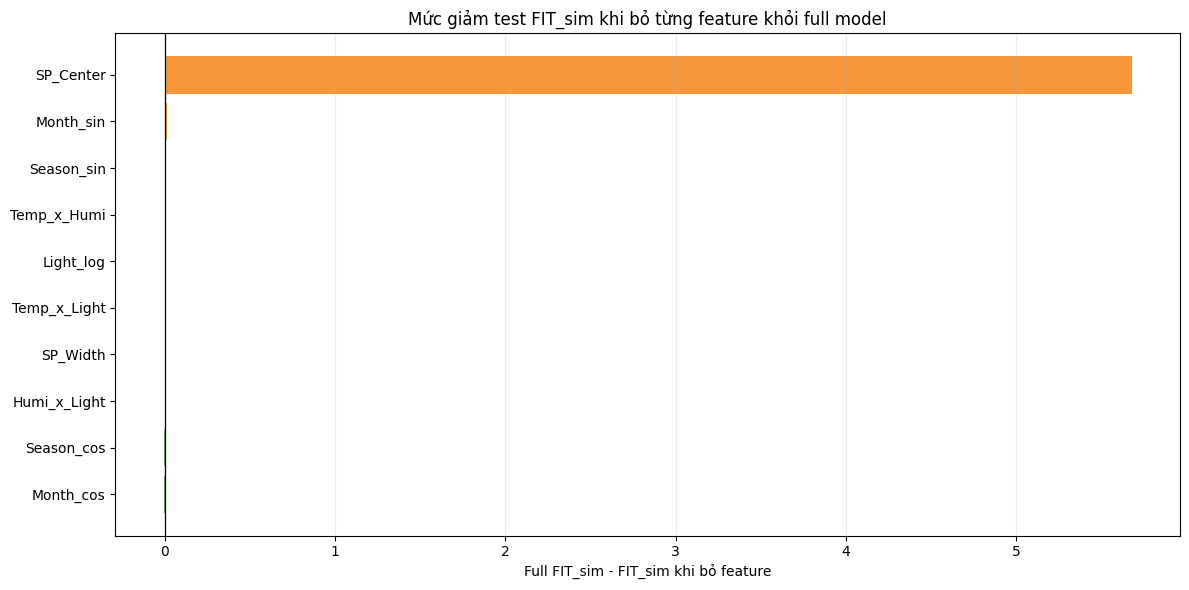

In [7]:
loo_plot = loo_df[loo_df["label"].str.startswith("Full minus")].copy()
loo_plot["removed_feature"] = loo_plot["label"].str.replace("Full minus ", "", regex=False)
loo_plot = loo_plot.sort_values("drop_test_FIT_sim_vs_full", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = np.where(loo_plot["drop_test_FIT_sim_vs_full"] >= 0, "#f58518", "#54a24b")
ax.barh(loo_plot["removed_feature"], loo_plot["drop_test_FIT_sim_vs_full"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Mức giảm test FIT_sim khi bỏ từng feature khỏi full model")
ax.set_xlabel("Full FIT_sim - FIT_sim khi bỏ feature")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


## 6. Thí nghiệm 3 - Ablation theo nhóm feature


In [8]:
group_rows = []
group_rows.append(fit_and_score("Baseline: 6 raw inputs", baseline_inputs))
for group_name, feats in FEATURE_GROUPS.items():
    group_rows.append(fit_and_score(f"+ group {group_name}", tuple(BASELINE_INPUT_COLS + feats)))
group_rows.append(fit_and_score("Full: all groups", full_inputs))

group_df = pd.DataFrame(group_rows)
group_df["gain_test_FIT_sim_vs_baseline"] = group_df["test_FIT_sim"] - baseline_test
group_df["gain_val_FIT_sim_vs_baseline"] = group_df["val_FIT_sim"] - baseline_val
display(group_df[[
    "label", "n_inputs", "best_alpha", "val_FIT_sim", "test_FIT_sim", "test_RMSE_sim",
    "gain_val_FIT_sim_vs_baseline", "gain_test_FIT_sim_vs_baseline",
]].round(4))


,label,n_inputs,best_alpha,val_FIT_sim,test_FIT_sim,test_RMSE_sim,gain_val_FIT_sim_vs_baseline,gain_test_FIT_sim_vs_baseline
0,Baseline: 6 raw inputs,6,100.0,54.0059,30.2629,2.0314,0.0000,0.0000
1,+ group Light transform,7,100.0,54.0060,30.3541,2.0287,0.0001,0.0913
2,+ group Environment interactions,9,100.0,54.0077,30.4384,2.0262,0.0017,0.1755
3,+ group Setpoint context,8,0.0,68.8571,66.3914,0.9790,14.8511,36.1286
4,+ group Month cyclic,8,0.0,59.5311,60.9358,1.1379,5.5252,30.6730
5,+ group Season cyclic,8,0.0,64.5021,49.9622,1.4575,10.4962,19.6993
6,Full: all groups,16,0.0,68.8411,66.4176,0.9782,14.8351,36.1547


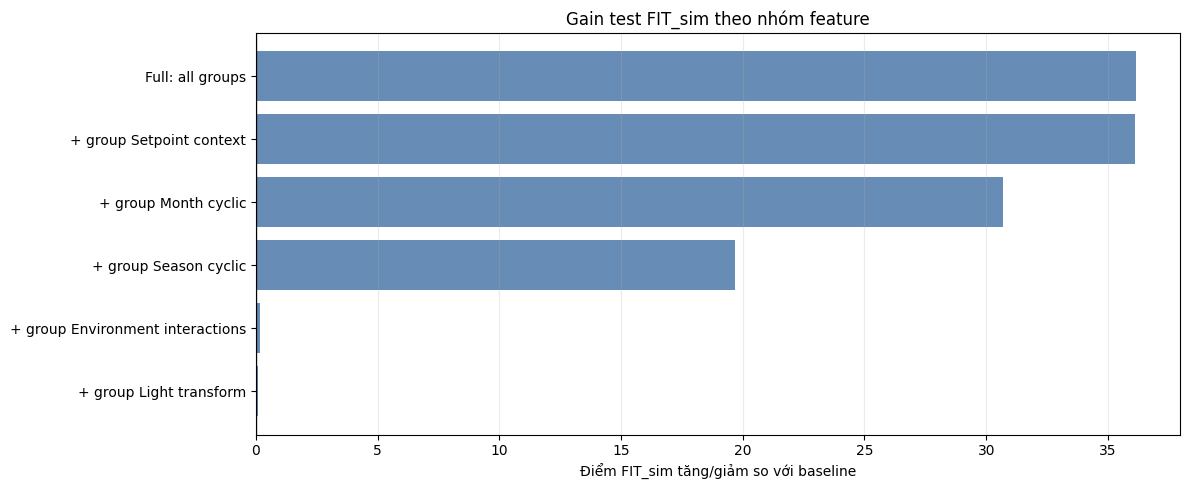

In [9]:
group_plot = group_df[~group_df["label"].str.startswith("Baseline")].copy()
group_plot = group_plot.sort_values("gain_test_FIT_sim_vs_baseline", ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(group_plot["label"], group_plot["gain_test_FIT_sim_vs_baseline"], color="#4c78a8", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Gain test FIT_sim theo nhóm feature")
ax.set_xlabel("Điểm FIT_sim tăng/giảm so với baseline")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


## 7. Thí nghiệm 4 - Kiểm tra từng input gốc


In [10]:
raw_rows = []
raw_rows.append(fit_and_score("AR only: no external input", tuple()))
for raw in BASELINE_INPUT_COLS:
    raw_rows.append(fit_and_score(f"AR + only {raw}", (raw,)))
raw_rows.append(fit_and_score("AR + all 6 raw inputs", baseline_inputs))

raw_input_df = pd.DataFrame(raw_rows)
ar_only_test = float(raw_input_df.loc[raw_input_df["label"].eq("AR only: no external input"), "test_FIT_sim"].iloc[0])
raw_input_df["gain_test_FIT_sim_vs_AR_only"] = raw_input_df["test_FIT_sim"] - ar_only_test
display(raw_input_df[[
    "label", "n_inputs", "best_alpha", "val_FIT_sim", "test_FIT_sim", "test_RMSE_sim",
    "gain_test_FIT_sim_vs_AR_only",
]].round(4))


,label,n_inputs,best_alpha,val_FIT_sim,test_FIT_sim,test_RMSE_sim,gain_test_FIT_sim_vs_AR_only
0,AR only: no external input,0,100.0,-0.3808,-24.5383,3.6276,0.0000
1,AR + only Temperature,1,100.0,-0.8061,-23.3732,3.5937,1.1651
2,AR + only Humidity,1,100.0,-0.5037,-24.4324,3.6246,0.1059
3,AR + only Light,1,0.0,-0.4022,-24.4391,3.6248,0.0992
4,AR + only Drip,1,0.0,21.9117,6.8068,2.7146,31.3450
5,AR + only Mist,1,100.0,-0.1412,-23.8916,3.6088,0.6466
6,AR + only Fan,1,100.0,-0.4622,-24.2164,3.6183,0.3218
7,AR + all 6 raw inputs,6,100.0,54.0059,30.2629,2.0314,54.8011


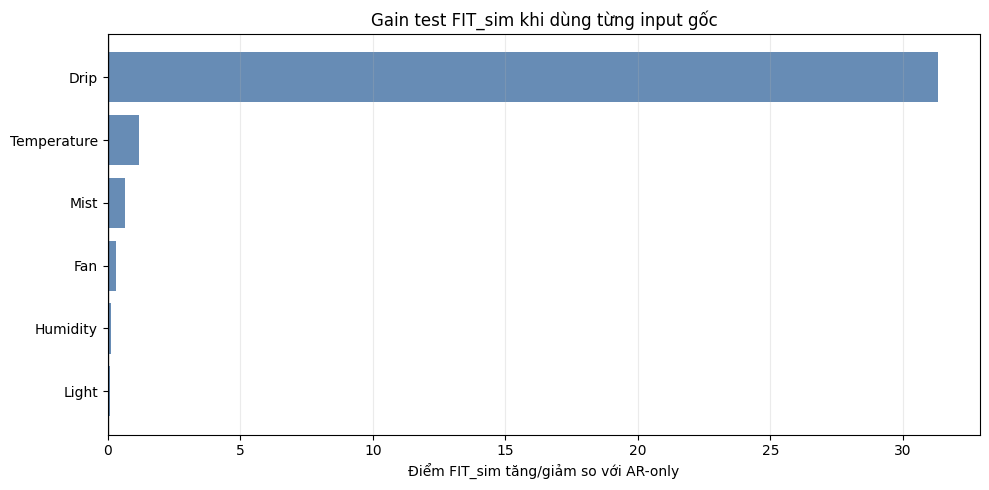

In [11]:
raw_plot = raw_input_df[raw_input_df["label"].str.startswith("AR + only")].copy()
raw_plot["raw_input"] = raw_plot["label"].str.replace("AR + only ", "", regex=False)
raw_plot = raw_plot.sort_values("gain_test_FIT_sim_vs_AR_only", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = np.where(raw_plot["gain_test_FIT_sim_vs_AR_only"] >= 0, "#4c78a8", "#e45756")
ax.barh(raw_plot["raw_input"], raw_plot["gain_test_FIT_sim_vs_AR_only"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Gain test FIT_sim khi dùng từng input gốc")
ax.set_xlabel("Điểm FIT_sim tăng/giảm so với AR-only")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


## 8. Kết luận tự động cho báo cáo


In [12]:
single_rank = (
    single_feature_df[~single_feature_df["label"].str.startswith("Baseline") & ~single_feature_df["label"].str.startswith("Full")]
    .assign(feature=lambda d: d["label"].str.replace("+ only ", "", regex=False))
    .sort_values("gain_test_FIT_sim_vs_baseline", ascending=False)
)
loo_rank = (
    loo_df[loo_df["label"].str.startswith("Full minus")]
    .assign(removed_feature=lambda d: d["label"].str.replace("Full minus ", "", regex=False))
    .sort_values("drop_test_FIT_sim_vs_full", ascending=False)
)
group_rank = (
    group_df[~group_df["label"].str.startswith("Baseline") & ~group_df["label"].str.startswith("Full")]
    .sort_values("gain_test_FIT_sim_vs_baseline", ascending=False)
)

top_single = single_rank.iloc[0]
top_loo = loo_rank.iloc[0]
top_group = group_rank.iloc[0]

summary_lines = [
    f"Baseline 6 raw inputs có test FIT_sim = {baseline_test:.2f}%.",
    f"Full feature engineering có test FIT_sim = {full_test:.2f}%.",
    f"Feature riêng lẻ tốt nhất là {top_single['feature']} với gain test FIT_sim = {top_single['gain_test_FIT_sim_vs_baseline']:.2f} điểm.",
    f"Khi bỏ từng feature khỏi full model, feature làm giảm test FIT_sim nhiều nhất khi bị bỏ là {top_loo['removed_feature']} với mức giảm {top_loo['drop_test_FIT_sim_vs_full']:.2f} điểm.",
    f"Nhóm feature riêng lẻ tốt nhất là {top_group['label']} với gain test FIT_sim = {top_group['gain_test_FIT_sim_vs_baseline']:.2f} điểm.",
]

for line in summary_lines:
    print("-", line)


- Baseline 6 raw inputs có test FIT_sim = 30.26%.
- Full feature engineering có test FIT_sim = 66.42%.
- Feature riêng lẻ tốt nhất là SP_Center với gain test FIT_sim = 36.13 điểm.
- Khi bỏ từng feature khỏi full model, feature làm giảm test FIT_sim nhiều nhất khi bị bỏ là SP_Center với mức giảm 5.68 điểm.
- Nhóm feature riêng lẻ tốt nhất là + group Setpoint context với gain test FIT_sim = 36.13 điểm.


## 9. Lưu bảng kết quả


In [13]:
out_dir = VERSION_DIR
single_feature_df.to_csv(out_dir / "arx_512_feature_ablation_single.csv", index=False)
loo_df.to_csv(out_dir / "arx_512_feature_ablation_leave_one_out.csv", index=False)
group_df.to_csv(out_dir / "arx_512_feature_ablation_groups.csv", index=False)
raw_input_df.to_csv(out_dir / "arx_512_raw_input_ablation.csv", index=False)

{
    "single_feature": str(out_dir / "arx_512_feature_ablation_single.csv"),
    "leave_one_out": str(out_dir / "arx_512_feature_ablation_leave_one_out.csv"),
    "groups": str(out_dir / "arx_512_feature_ablation_groups.csv"),
    "raw_inputs": str(out_dir / "arx_512_raw_input_ablation.csv"),
}


{'single_feature': 'C:\\Users\\minht\\OneDrive\\Desktop\\ARX-Model\\ARX_Model_Version 512\\arx_512_feature_ablation_single.csv',
 'leave_one_out': 'C:\\Users\\minht\\OneDrive\\Desktop\\ARX-Model\\ARX_Model_Version 512\\arx_512_feature_ablation_leave_one_out.csv',
 'groups': 'C:\\Users\\minht\\OneDrive\\Desktop\\ARX-Model\\ARX_Model_Version 512\\arx_512_feature_ablation_groups.csv',
 'raw_inputs': 'C:\\Users\\minht\\OneDrive\\Desktop\\ARX-Model\\ARX_Model_Version 512\\arx_512_raw_input_ablation.csv'}